In [1]:
import os
import json
import random
import collections
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('dataset.csv')
df

,index,YEAR,LocationAbbr,LocationDesc,TopicType,TopicDesc,MeasureDesc,DataSource,Response,Data_Value_Unit,...,GeoLocation,TopicTypeId,TopicId,MeasureId,StratificationID1,StratificationID2,StratificationID3,StratificationID4,SubMeasureID,DisplayOrder
0,0,2014,AL,Alabama,Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Status,BRFSS,Current,%,...,"(32.84057112200048, -86.63186076199969)",BEH,100BEH,165SSA,1GEN,8AGE,6RAC,6EDU,BRF27,27
1,1,2014,AL,Alabama,Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Status,BRFSS,Current,%,...,"(32.84057112200048, -86.63186076199969)",BEH,100BEH,165SSA,2GEN,8AGE,6RAC,6EDU,BRF27,27
2,2,2014,AL,Alabama,Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Status,BRFSS,Current,%,...,"(32.84057112200048, -86.63186076199969)",BEH,100BEH,165SSA,3GEN,8AGE,6RAC,6EDU,BRF27,27
3,3,2014,AL,Alabama,Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Frequency,BRFSS,Some Days,%,...,"(32.84057112200048, -86.63186076199969)",BEH,100BEH,166SSP,1GEN,8AGE,6RAC,6EDU,BRF26,26
4,4,2014,AL,Alabama,Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Frequency,BRFSS,Some Days,%,...,"(32.84057112200048, -86.63186076199969)",BEH,100BEH,166SSP,2GEN,8AGE,6RAC,6EDU,BRF26,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11671,11671,2014-2015,PR,Puerto Rico,Tobacco Use – Survey Data,Cigarette Use (Adults),Current Smoking – (2 yrs – Race/Ethnicity),BRFSS,NaN,%,...,"(18.220833, -66.590149)",BEH,100BEH,112CS2,1GEN,8AGE,5RAC,6EDU,BRF34,34
11672,11672,2014-2015,PR,Puerto Rico,Tobacco Use – Survey Data,Cigarette Use (Adults),Current Smoking – (2 yrs – Race/Ethnicity),BRFSS,NaN,%,...,"(18.220833, -66.590149)",BEH,100BEH,112CS2,1GEN,8AGE,1RAC,6EDU,BRF30,30
11673,11673,2014-2015,PR,Puerto Rico,Tobacco Use – Survey Data,Cigarette Use (Adults),Current Smoking – (2 yrs – Race/Ethnicity),BRFSS,NaN,%,...,"(18.220833, -66.590149)",BEH,100BEH,112CS2,1GEN,8AGE,4RAC,6EDU,BRF33,33
11674,11674,2014-2015,PR,Puerto Rico,Tobacco Use – Survey Data,Cigarette Use (Adults),Current Smoking – (2 yrs – Race/Ethnicity),BRFSS,NaN,%,...,"(18.220833, -66.590149)",BEH,100BEH,112CS2,1GEN,8AGE,3RAC,6EDU,BRF32,32


In [3]:
df.describe()

,index,Data_Value,Data_Value_Std_Err,Low_Confidence_Limit,High_Confidence_Limit,Sample_Size,DisplayOrder
count,11676.000000,11374.000000,11358.000000,11358.000000,11358.000000,11358.000000,11676.000000
mean,5837.500000,32.367171,1.898838,28.642208,36.077690,3120.019458,23.423004
std,3370.715206,18.582925,1.471922,18.207930,19.384479,3655.885118,7.643647
min,0.000000,0.600000,0.300000,0.000000,1.700000,50.000000,5.000000
25%,2918.750000,18.500000,0.900000,15.600000,21.000000,644.250000,22.000000
50%,5837.500000,25.500000,1.400000,22.000000,29.000000,1876.500000,24.000000
75%,8756.250000,49.175000,2.400000,44.200000,53.800000,4226.000000,27.250000
max,11675.000000,87.900000,14.900000,85.400000,90.400000,39839.000000,45.000000


In [4]:
df.isnull().sum()

index                             0
YEAR                              0
LocationAbbr                      0
LocationDesc                      0
TopicType                         0
TopicDesc                         0
MeasureDesc                       0
DataSource                        0
Response                       7693
Data_Value_Unit                   0
Data_Value_Type                   0
Data_Value                      302
Data_Value_Footnote_Symbol    11374
Data_Value_Footnote           11374
Data_Value_Std_Err              318
Low_Confidence_Limit            318
High_Confidence_Limit           318
Sample_Size                     318
Gender                            0
Race                              0
Age                               0
Education                         0
GeoLocation                       0
TopicTypeId                       0
TopicId                           0
MeasureId                         0
StratificationID1                 0
StratificationID2           

In [5]:
df.dtypes

index                           int64
YEAR                           object
LocationAbbr                   object
LocationDesc                   object
TopicType                      object
TopicDesc                      object
MeasureDesc                    object
DataSource                     object
Response                       object
Data_Value_Unit                object
Data_Value_Type                object
Data_Value                    float64
Data_Value_Footnote_Symbol     object
Data_Value_Footnote            object
Data_Value_Std_Err            float64
Low_Confidence_Limit          float64
High_Confidence_Limit         float64
Sample_Size                   float64
Gender                         object
Race                           object
Age                            object
Education                      object
GeoLocation                    object
TopicTypeId                    object
TopicId                        object
MeasureId                      object
Stratificati

In [6]:
empty_cols = []
for col in df.columns:
    if df[col].isnull().values.any():
        empty_cols.append(col)

if len(empty_cols) > 0:
    print("Columns with empty cells:")
    for col in empty_cols:
        print(f"{col} ({df[col].dtype})")
else:
    print("No columns with empty cells found.")

Columns with empty cells:
Response (object)
Data_Value (float64)
Data_Value_Footnote_Symbol (object)
Data_Value_Footnote (object)
Data_Value_Std_Err (float64)
Low_Confidence_Limit (float64)
High_Confidence_Limit (float64)
Sample_Size (float64)


In [7]:
df = df[~df.apply(lambda row: row.astype(str).str.contains('Data in these cells have been suppressed because of a small sample size').any(), axis=1)]

In [8]:
df.head()

,index,YEAR,LocationAbbr,LocationDesc,TopicType,TopicDesc,MeasureDesc,DataSource,Response,Data_Value_Unit,...,GeoLocation,TopicTypeId,TopicId,MeasureId,StratificationID1,StratificationID2,StratificationID3,StratificationID4,SubMeasureID,DisplayOrder
0,0,2014,AL,Alabama,Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Status,BRFSS,Current,%,...,"(32.84057112200048, -86.63186076199969)",BEH,100BEH,165SSA,1GEN,8AGE,6RAC,6EDU,BRF27,27
1,1,2014,AL,Alabama,Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Status,BRFSS,Current,%,...,"(32.84057112200048, -86.63186076199969)",BEH,100BEH,165SSA,2GEN,8AGE,6RAC,6EDU,BRF27,27
2,2,2014,AL,Alabama,Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Status,BRFSS,Current,%,...,"(32.84057112200048, -86.63186076199969)",BEH,100BEH,165SSA,3GEN,8AGE,6RAC,6EDU,BRF27,27
3,3,2014,AL,Alabama,Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Frequency,BRFSS,Some Days,%,...,"(32.84057112200048, -86.63186076199969)",BEH,100BEH,166SSP,1GEN,8AGE,6RAC,6EDU,BRF26,26
4,4,2014,AL,Alabama,Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Frequency,BRFSS,Some Days,%,...,"(32.84057112200048, -86.63186076199969)",BEH,100BEH,166SSP,2GEN,8AGE,6RAC,6EDU,BRF26,26


In [9]:
df.shape

(11374, 32)

In [10]:
df = df.drop('Data_Value_Footnote_Symbol', axis=1)

In [11]:
df = df.drop('Data_Value_Footnote', axis=1)

In [12]:
df.isnull().sum()

index                       0
YEAR                        0
LocationAbbr                0
LocationDesc                0
TopicType                   0
TopicDesc                   0
MeasureDesc                 0
DataSource                  0
Response                 7391
Data_Value_Unit             0
Data_Value_Type             0
Data_Value                  0
Data_Value_Std_Err         16
Low_Confidence_Limit       16
High_Confidence_Limit      16
Sample_Size                16
Gender                      0
Race                        0
Age                         0
Education                   0
GeoLocation                 0
TopicTypeId                 0
TopicId                     0
MeasureId                   0
StratificationID1           0
StratificationID2           0
StratificationID3           0
StratificationID4           0
SubMeasureID                0
DisplayOrder                0
dtype: int64

In [13]:
df.dropna(subset=['Response'], inplace=True)

In [14]:
df.shape

(3983, 30)

In [15]:
df.isnull().sum()

index                    0
YEAR                     0
LocationAbbr             0
LocationDesc             0
TopicType                0
TopicDesc                0
MeasureDesc              0
DataSource               0
Response                 0
Data_Value_Unit          0
Data_Value_Type          0
Data_Value               0
Data_Value_Std_Err       8
Low_Confidence_Limit     8
High_Confidence_Limit    8
Sample_Size              8
Gender                   0
Race                     0
Age                      0
Education                0
GeoLocation              0
TopicTypeId              0
TopicId                  0
MeasureId                0
StratificationID1        0
StratificationID2        0
StratificationID3        0
StratificationID4        0
SubMeasureID             0
DisplayOrder             0
dtype: int64

In [16]:
df.dropna(subset=['Data_Value_Std_Err'], inplace=True)

In [17]:
df.isnull().sum()

index                    0
YEAR                     0
LocationAbbr             0
LocationDesc             0
TopicType                0
TopicDesc                0
MeasureDesc              0
DataSource               0
Response                 0
Data_Value_Unit          0
Data_Value_Type          0
Data_Value               0
Data_Value_Std_Err       0
Low_Confidence_Limit     0
High_Confidence_Limit    0
Sample_Size              0
Gender                   0
Race                     0
Age                      0
Education                0
GeoLocation              0
TopicTypeId              0
TopicId                  0
MeasureId                0
StratificationID1        0
StratificationID2        0
StratificationID3        0
StratificationID4        0
SubMeasureID             0
DisplayOrder             0
dtype: int64

In [18]:
for col in df.columns:
    print(f"Unique values for column {col}:")
    print(df[col].unique())
    print()

Unique values for column index:
[    0     1     2 ... 11408 11409 11410]

Unique values for column YEAR:
['2014' '2013' '2012' '2011' '2015']

Unique values for column LocationAbbr:
['AL' 'AK' 'AZ' 'AR' 'CA' 'CO' 'CT' 'DE' 'DC' 'FL' 'GA' 'GU' 'HI' 'ID'
 'IL' 'IN' 'IA' 'KS' 'KY' 'LA' 'ME' 'MD' 'MA' 'MI' 'MN' 'MS' 'MO' 'MT'
 'NE' 'NV' 'NH' 'NJ' 'NM' 'NY' 'NC' 'ND' 'OH' 'OK' 'OR' 'PA' 'PR' 'RI'
 'SC' 'SD' 'TN' 'TX' 'UT' 'VT' 'VA' 'WA' 'WV' 'WI' 'WY']

Unique values for column LocationDesc:
['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Colorado'
 'Connecticut' 'Delaware' 'District of Columbia' 'Florida' 'Georgia'
 'Guam' 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky'
 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota'
 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire'
 'New Jersey' 'New Mexico' 'New York' 'North Carolina' 'North Dakota'
 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania' 'Puerto Rico' 'Rhode Island'
 'South Carolin

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3975 entries, 0 to 11410
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   index                  3975 non-null   int64  
 1   YEAR                   3975 non-null   object 
 2   LocationAbbr           3975 non-null   object 
 3   LocationDesc           3975 non-null   object 
 4   TopicType              3975 non-null   object 
 5   TopicDesc              3975 non-null   object 
 6   MeasureDesc            3975 non-null   object 
 7   DataSource             3975 non-null   object 
 8   Response               3975 non-null   object 
 9   Data_Value_Unit        3975 non-null   object 
 10  Data_Value_Type        3975 non-null   object 
 11  Data_Value             3975 non-null   float64
 12  Data_Value_Std_Err     3975 non-null   float64
 13  Low_Confidence_Limit   3975 non-null   float64
 14  High_Confidence_Limit  3975 non-null   float64
 15  Sam

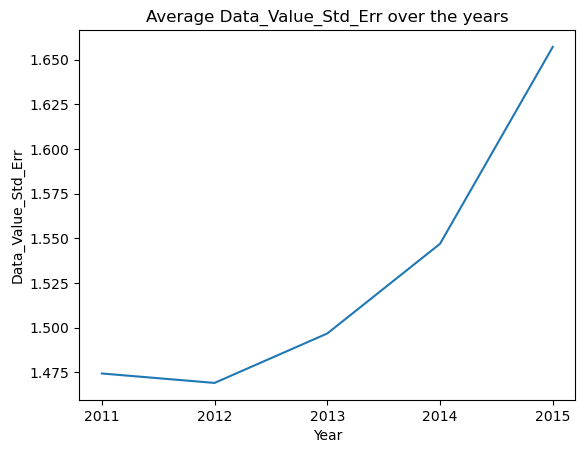

In [20]:
std_err_by_year = df.groupby('YEAR')['Data_Value_Std_Err'].mean()

# Create a line chart
plt.plot(std_err_by_year.index, std_err_by_year.values)
plt.title('Average Data_Value_Std_Err over the years')
plt.xlabel('Year')
plt.ylabel('Data_Value_Std_Err')
plt.show()

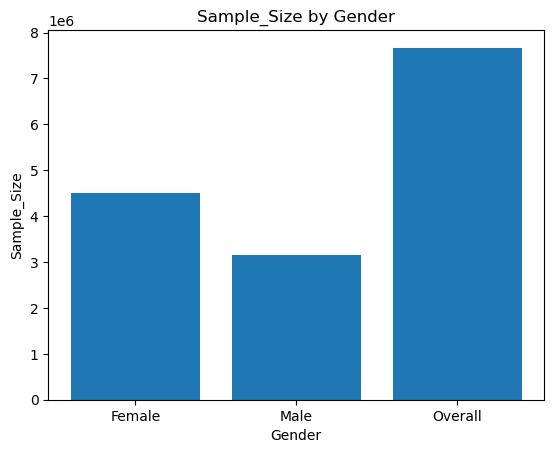

In [21]:
sample_size_by_gender = df.groupby('Gender')['Sample_Size'].sum()

# Create a bar chart
plt.bar(sample_size_by_gender.index, sample_size_by_gender.values)
plt.title('Sample_Size by Gender')
plt.xlabel('Gender')
plt.ylabel('Sample_Size')
plt.show()

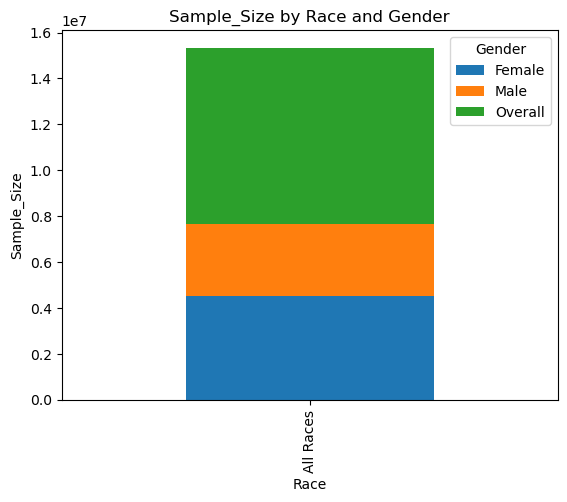

In [22]:
sample_size_by_race_gender = df.groupby(['Race', 'Gender'])['Sample_Size'].sum()

# Create a stacked bar chart
sample_size_by_race_gender.unstack().plot(kind='bar', stacked=True)
plt.title('Sample_Size by Race and Gender')
plt.xlabel('Race')
plt.ylabel('Sample_Size')
plt.show()

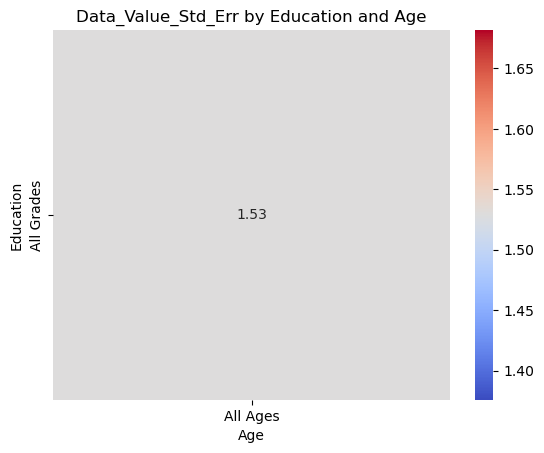

In [23]:
std_err_by_edu_age = pd.pivot_table(df, values='Data_Value_Std_Err', index='Education', columns='Age')

# Create a heatmap using seaborn
sns.heatmap(std_err_by_edu_age, cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Data_Value_Std_Err by Education and Age')
plt.xlabel('Age')
plt.ylabel('Education')
plt.show()


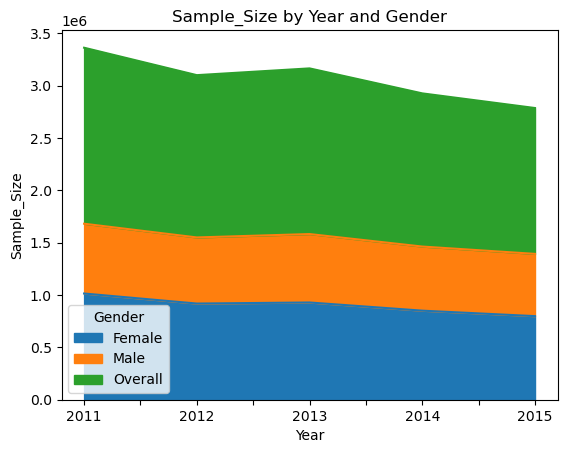

In [24]:
sample_size_by_year_gender = df.groupby(['YEAR', 'Gender'])['Sample_Size'].sum()

# Pivot the data to create a stacked area chart
sample_size_by_year_gender = sample_size_by_year_gender.unstack()
sample_size_by_year_gender.plot(kind='area', stacked=True)

# Create a stacked area chart
plt.title('Sample_Size by Year and Gender')
plt.xlabel('Year')
plt.ylabel('Sample_Size')
plt.show()

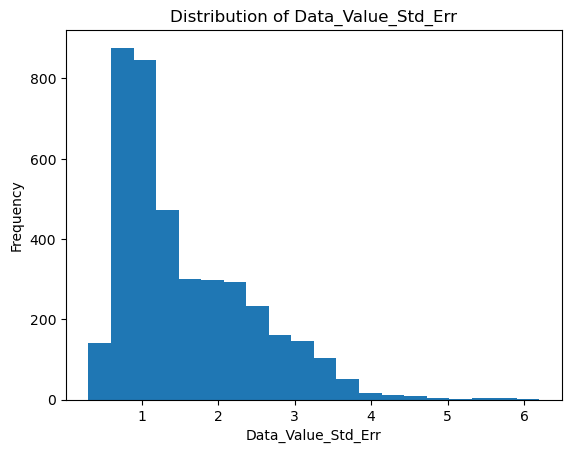

In [25]:
plt.hist(df['Data_Value_Std_Err'], bins=20)
plt.title('Distribution of Data_Value_Std_Err')
plt.xlabel('Data_Value_Std_Err')
plt.ylabel('Frequency')
plt.show()

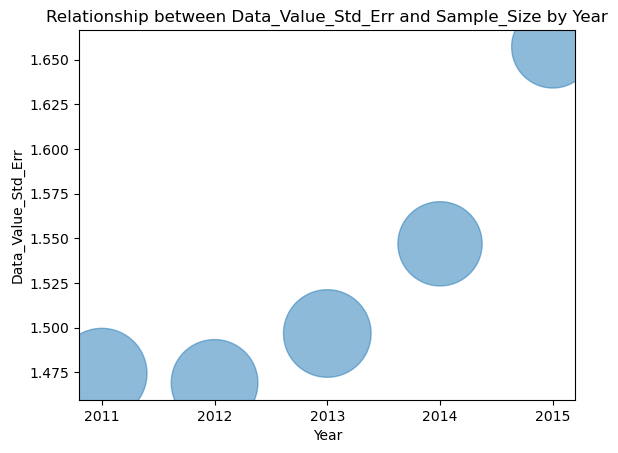

In [26]:
data_by_year = df.groupby('YEAR').agg({'Data_Value_Std_Err': 'mean', 'Sample_Size': 'mean'})

# Create a scatter plot of Data_Value_Std_Err and Sample_Size by year
plt.scatter(data_by_year.index, data_by_year['Data_Value_Std_Err'], s=data_by_year['Sample_Size'], alpha=0.5)
plt.title('Relationship between Data_Value_Std_Err and Sample_Size by Year')
plt.xlabel('Year')
plt.ylabel('Data_Value_Std_Err')
plt.show()

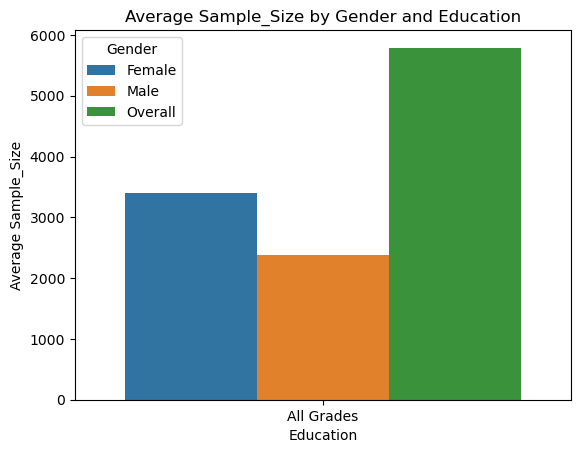

In [27]:
avg_sample_size = df.groupby(['Gender', 'Education'])['Sample_Size'].mean().reset_index()

# Create a bar chart of average Sample_Size by gender and education
sns.barplot(x='Education', y='Sample_Size', hue='Gender', data=avg_sample_size)
plt.title('Average Sample_Size by Gender and Education')
plt.xlabel('Education')
plt.ylabel('Average Sample_Size')
plt.show()

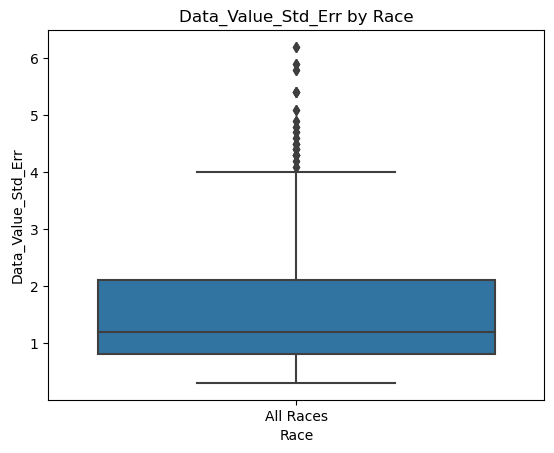

In [28]:
import seaborn as sns
sns.boxplot(x='Race', y='Data_Value_Std_Err', data=df)
plt.title('Data_Value_Std_Err by Race')
plt.xlabel('Race')
plt.ylabel('Data_Value_Std_Err')
plt.show()

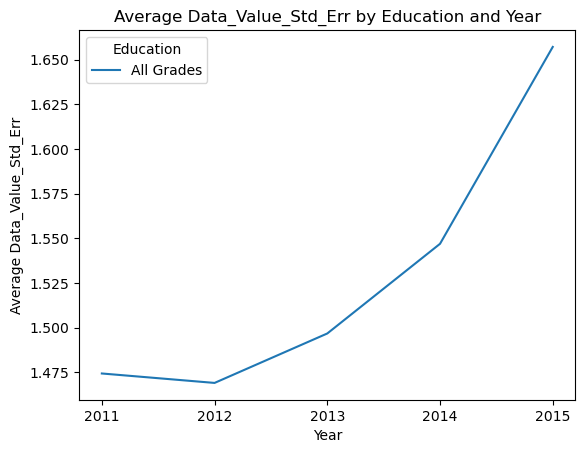

In [29]:
avg_std_err_by_edu_year = df.groupby(['YEAR', 'Education'])['Data_Value_Std_Err'].mean().reset_index()

# Create a line chart of average Data_Value_Std_Err by education and year
sns.lineplot(x='YEAR', y='Data_Value_Std_Err', hue='Education', data=avg_std_err_by_edu_year)
plt.title('Average Data_Value_Std_Err by Education and Year')
plt.xlabel('Year')
plt.ylabel('Average Data_Value_Std_Err')
plt.show()

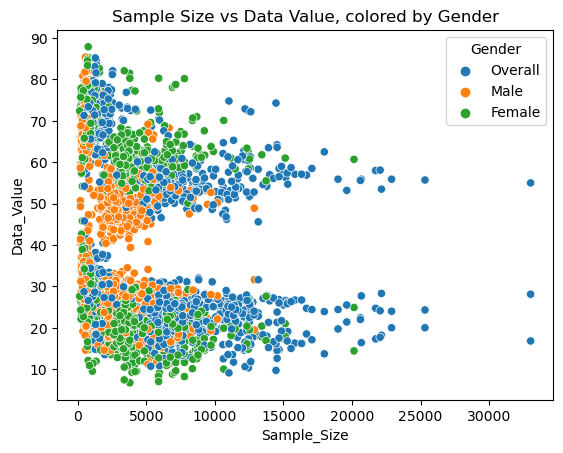

In [30]:
sns.scatterplot(x='Sample_Size', y='Data_Value', hue='Gender', data=df)
plt.title('Sample Size vs Data Value, colored by Gender')
plt.show()

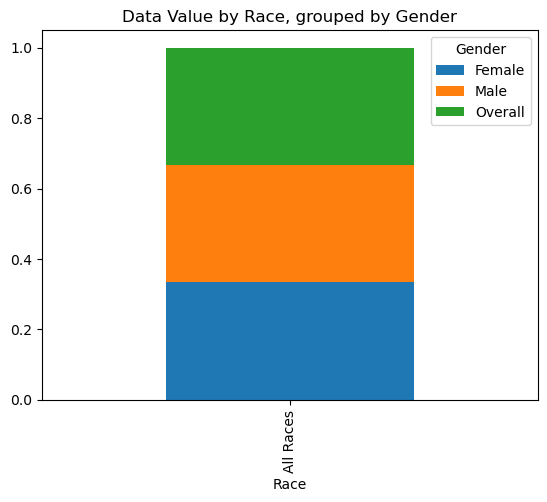

In [31]:
pd.crosstab(df['Race'], df['Gender'], values=df['Data_Value'], aggfunc='mean', normalize='index').plot(kind='bar', stacked=True)
plt.title('Data Value by Race, grouped by Gender')
plt.show()


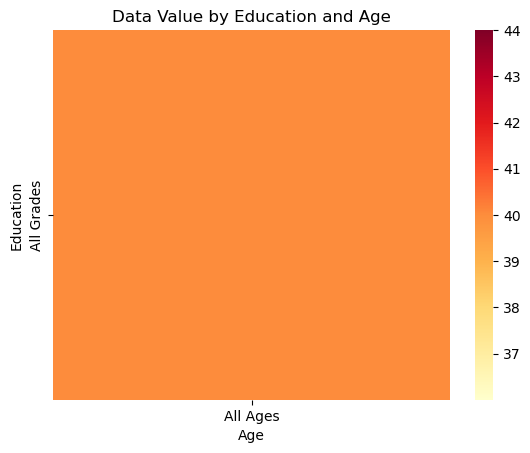

In [32]:
pivot_table = pd.pivot_table(df, values='Data_Value', index='Education', columns='Age', aggfunc='mean')
sns.heatmap(pivot_table, cmap='YlOrRd')
plt.title('Data Value by Education and Age')
plt.show()


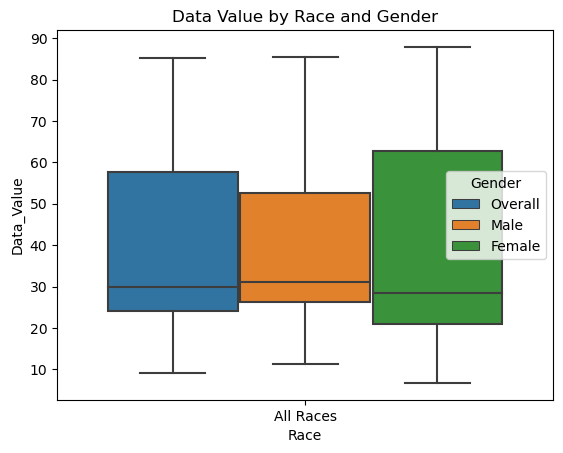

In [33]:
sns.boxplot(x='Race', y='Data_Value', hue='Gender', data=df)
plt.title('Data Value by Race and Gender')
plt.show()

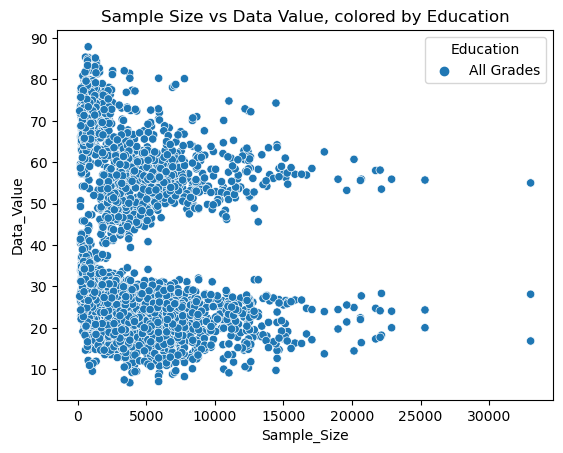

In [34]:
sns.scatterplot(x='Sample_Size', y='Data_Value', hue='Education', data=df)
plt.title('Sample Size vs Data Value, colored by Education')
plt.show()

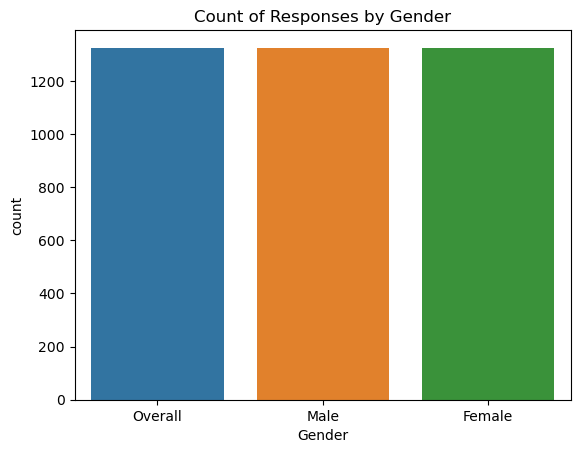

In [35]:
sns.countplot(x='Gender', data=df)
plt.title('Count of Responses by Gender')
plt.show()


## Outliers in Sample_Size

In [36]:
Q1 = df['Sample_Size'].quantile(0.25)
Q3 = df['Sample_Size'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Sample_Size'] < lower_bound) | (df['Sample_Size'] > upper_bound)]

print(outliers)

      index  YEAR LocationAbbr LocationDesc                  TopicType  \
128     128  2014           AZ      Arizona  Tobacco Use – Survey Data   
131     131  2014           AZ      Arizona  Tobacco Use – Survey Data   
134     134  2014           AZ      Arizona  Tobacco Use – Survey Data   
803     803  2014           KS       Kansas  Tobacco Use – Survey Data   
806     806  2014           KS       Kansas  Tobacco Use – Survey Data   
...     ...   ...          ...          ...                        ...   
9660   9660  2015           KS       Kansas  Tobacco Use – Survey Data   
9681   9681  2015           MN    Minnesota  Tobacco Use – Survey Data   
9693   9693  2015           NE     Nebraska  Tobacco Use – Survey Data   
9741   9741  2015           TX        Texas  Tobacco Use – Survey Data   
9753   9753  2015           WA   Washington  Tobacco Use – Survey Data   

                   TopicDesc     MeasureDesc DataSource Response  \
128   Cigarette Use (Adults)  Smoking Statu

## Normalization

In [37]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['Data_Value_Std_Err'] = scaler.fit_transform(df[['Data_Value_Std_Err']])
df['Sample_Size'] = scaler.fit_transform(df[['Sample_Size']])
df[['Data_Value_Std_Err', 'Sample_Size']].head()

,Data_Value_Std_Err,Sample_Size
0,0.067797,0.249977
1,0.135593,0.086621
2,0.084746,0.158825
3,0.254237,0.040786
4,0.372881,0.014112


## Data encoding 

In [38]:
df = pd.get_dummies(df, columns=['Gender'])
df = pd.get_dummies(df, columns=['Race'])
df = pd.get_dummies(df, columns=['Age'])
df = pd.get_dummies(df, columns=['Education'])

In [39]:
df.head()

,index,YEAR,LocationAbbr,LocationDesc,TopicType,TopicDesc,MeasureDesc,DataSource,Response,Data_Value_Unit,...,StratificationID3,StratificationID4,SubMeasureID,DisplayOrder,Gender_Female,Gender_Male,Gender_Overall,Race_All Races,Age_All Ages,Education_All Grades
0,0,2014,AL,Alabama,Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Status,BRFSS,Current,%,...,6RAC,6EDU,BRF27,27,0,0,1,1,1,1
1,1,2014,AL,Alabama,Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Status,BRFSS,Current,%,...,6RAC,6EDU,BRF27,27,0,1,0,1,1,1
2,2,2014,AL,Alabama,Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Status,BRFSS,Current,%,...,6RAC,6EDU,BRF27,27,1,0,0,1,1,1
3,3,2014,AL,Alabama,Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Frequency,BRFSS,Some Days,%,...,6RAC,6EDU,BRF26,26,0,0,1,1,1,1
4,4,2014,AL,Alabama,Tobacco Use – Survey Data,Cigarette Use (Adults),Smoking Frequency,BRFSS,Some Days,%,...,6RAC,6EDU,BRF26,26,0,1,0,1,1,1


In [40]:
df.shape

(3975, 32)

## Feature Selection

In [41]:
data=pd.read_csv('dataset.csv')
corr_matrix = data.corr().abs()
num_features = 5
top_features = corr_matrix.nlargest(num_features, 'Data_Value')['Data_Value'].index
selected_data = data[top_features]
print(selected_data)

       Data_Value  High_Confidence_Limit  Low_Confidence_Limit  DisplayOrder  \
0            21.1                   22.4                  19.8            27   
1            23.5                   25.7                  21.3            27   
2            19.0                   20.6                  17.4            27   
3            30.1                   33.6                  26.6            26   
4            29.0                   34.0                  24.0            26   
...           ...                    ...                   ...           ...   
11671        16.6                   28.6                   4.6            34   
11672         NaN                    NaN                   NaN            30   
11673        10.9                   11.7                  10.1            33   
11674         NaN                    NaN                   NaN            32   
11675         NaN                    NaN                   NaN            31   

       Data_Value_Std_Err  
0          